# Multilingual Narrative Harvesting & Structured Policy Action Classification

**How can we systematically harvest, score, and classify policy announcements from text across multiple languages into structured macroeconomic shocks?**

Macroeconomic policy identification has increasingly turned to the **narrative approach** (Romer & Romer 2010 *AER*, Ramey 2011 *QJE*, Cloyne 2013 *AER*, Mertens & Ravn 2013 *AER*):

1. **Multi-Source Institutional Harvesting**:
   Capturing real-time decisions, press releases, budget plans, and speeches directly from central banks, fiscal ministries, and multilateral institutions.

2. **Multilingual Macroeconomic Lexicons (8 Languages)**:
   Quantifying policy stance and sentiment across English (`en`), Spanish (`es`), Portuguese (`pt`), German (`de`), French (`fr`), Italian (`it`), Japanese (`ja`), and Chinese (`zh`) using domain-specific macro lexicons:
   $$ \text{Net Sentiment} = \frac{\text{Expansion Terms} - \text{Contraction Terms}}{\text{Total Tokens}} \times 1000 $$

3. **Structured Policy Action Classification & Implementation Schedules**:
   Extracting explicit magnitudes ($\% \text{ of GDP}$, billions, basis points) and modeling empirical **realization lags** (e.g. S-curve for public infrastructure vs. front-loaded transfers) to produce validated `NarrativeEvent` objects.

In this notebook, we demonstrate the end-to-end narrative pipeline using `puremacro.narrative`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.narrative import (
    SOURCE_REGISTRY,
    NarrativeDocument,
    NarrativeCorpus,
    PolicyActionClassifier,
    score_multilingual,
    infer_policy_stance,
    estimate_implementation_profile,
)

## 1. Exploring the Unified 50+ Source Registry

`puremacro.narrative.harvest` maintains a curated registry of connectors covering central banks, fiscal agencies, and international organizations.

In [2]:
sources_list = []
for name, (mod, fn, country, domain, doc_type, lang) in SOURCE_REGISTRY.items():
    sources_list.append({
        "Source ID": name,
        "Country": country,
        "Domain": domain,
        "Doc Type": doc_type,
        "Language": lang,
    })

df_registry = pd.DataFrame(sources_list)
print(f"Total institutional sources registered: {len(df_registry)}")
print("\nSample of Registered Sources:")
print(df_registry.head(10))

# Distribution by Domain & Language
print("\nSource Count by Policy Domain:")
print(df_registry["Domain"].value_counts())

Total institutional sources registered: 54

Sample of Registered Sources:
             Source ID Country      Domain     Doc Type Language
0         fed_decision     USA    monetary     decision       en
1          fed_minutes     USA    monetary      minutes       en
2       fed_press_conf     USA    monetary   press_conf       en
3         fed_speeches     USA    monetary       speech       en
4           beige_book     USA    monetary       report       en
5               us_cbo     USA      fiscal       report       en
6               us_erp     USA      fiscal       report       en
7              us_sotu     USA      fiscal       speech       en
8  us_federal_register     USA  structural   regulation       en
9     us_dod_contracts     USA      fiscal  procurement       en

Source Count by Policy Domain:
Domain
monetary      35
fiscal        13
structural     5
general        1
Name: count, dtype: int64


## 2. Multilingual Macroeconomic Scoring Across 8 Languages

We evaluate official excerpts from 8 major economies in their native languages to determine net sentiment, policy direction, and uncertainty.

In [3]:
multilingual_corpus = [
    ("en", "USA", "The government announced a major fiscal stimulus and infrastructure investment package.", "fiscal"),
    ("en", "USA", "The Federal Reserve decided to hike rates and implement monetary tightening to curb inflation.", "monetary"),
    ("es", "MEX", "La Secretaría de Hacienda presentó un plan de estímulo fiscal con inversión pública e infraestructura.", "fiscal"),
    ("es", "COL", "La junta directiva decidió un alza de tasa de interés para contener las presiones inflacionarias.", "monetary"),
    ("pt", "BRA", "O governo aprovou um estímulo fiscal com aumento de gastos e investimento em infraestrutura.", "fiscal"),
    ("pt", "BRA", "O Copom determinou o corte da taxa selic e afrouxamento monetário para estimular a atividade.", "monetary"),
    ("de", "DEU", "Die Bundesregierung beschloss ein neues Konjunkturpaket und Steuersenkung für Unternehmen.", "fiscal"),
    ("de", "DEU", "Zur Haushaltskonsolidierung sind Ausgabenkürzung und Sparprogramm erforderlich.", "fiscal"),
    ("fr", "FRA", "Le gouvernement lance un vaste plan de relance et investissement public.", "fiscal"),
    ("it", "ITA", "Il governo ha varato un piano di stimolo e taglio delle tasse sugli investimenti.", "fiscal"),
    ("ja", "JPN", "政府は大規模な経済対策と財政出動、公共投資の拡大を決定した。", "fiscal"),
    ("zh", "CHN", "实施积极财政政策，加力提效，支持重大基础设施投资和专项债发行。", "fiscal"),
]

scoring_results = []
for lang, country, text, domain in multilingual_corpus:
    res = score_multilingual(text, language=lang, domain=domain)
    sign, conf, details = infer_policy_stance(text, language=lang, domain=domain)
    scoring_results.append({
        "Language": lang,
        "Country": country,
        "Domain": domain,
        "Tokens": res.token_count,
        "Net Sentiment": res.net_sentiment,
        "Expansion Rate (‰)": res.expansion_intensity,
        "Contraction Rate (‰)": res.contraction_intensity,
        "Inferred Sign": "+1 (Expansion)" if sign > 0 else ("-1 (Contraction)" if sign < 0 else "0 (Neutral)"),
        "Confidence": f"{conf:.2f}",
        "Matched Terms": ", ".join(res.matched_expansion_terms + res.matched_contraction_terms),
    })

df_scores = pd.DataFrame(scoring_results)
print("Multilingual Policy Scoring Table across 8 Languages:")
print(df_scores[["Language", "Country", "Domain", "Inferred Sign", "Confidence", "Matched Terms"]].to_string(index=False))

Multilingual Policy Scoring Table across 8 Languages:
Language Country   Domain    Inferred Sign Confidence                                                      Matched Terms
      en     USA   fiscal   +1 (Expansion)       0.95     fiscal stimulus, infrastructure investment, investment package
      en     USA monetary -1 (Contraction)       0.80                                    monetary tightening, hike rates
      es     MEX   fiscal   +1 (Expansion)       0.80                                 estímulo fiscal, inversión pública
      es     COL monetary -1 (Contraction)       0.65                                                       alza de tasa
      pt     BRA   fiscal   +1 (Expansion)       0.95 estímulo fiscal, investimento em infraestrutura, aumento de gastos
      pt     BRA monetary   +1 (Expansion)       0.80                        corte da taxa selic, afrouxamento monetário
      de     DEU   fiscal   +1 (Expansion)       0.80                                     konjunktu

## 3. Visualizing Sentiment Intensities Across Languages

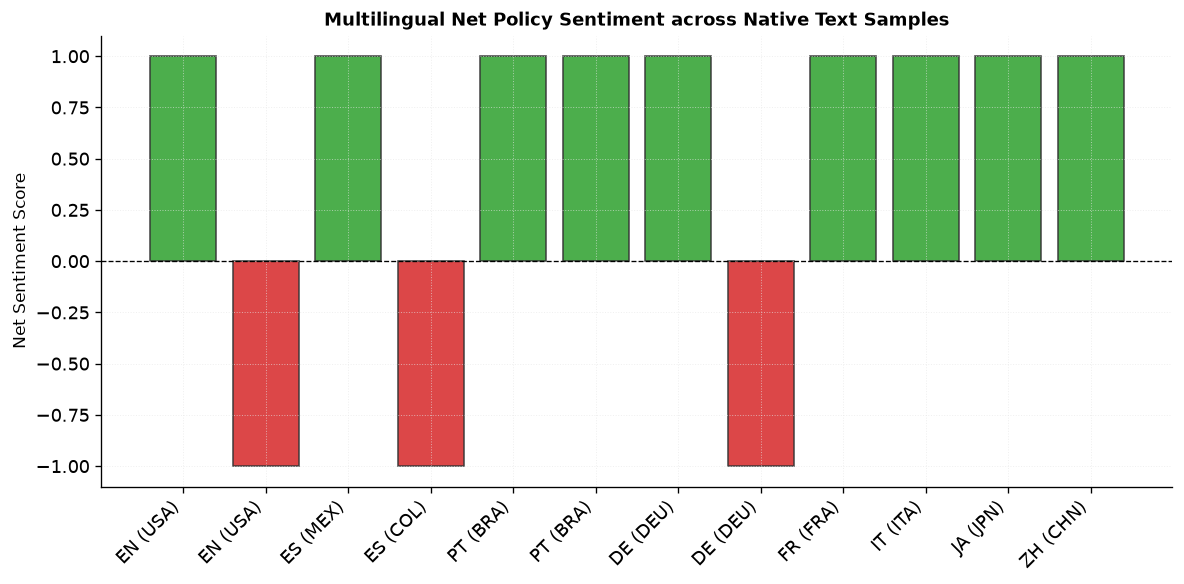

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

languages = [r["Language"].upper() + f" ({r['Country']})" for r in scoring_results]
net_sentiments = [r["Net Sentiment"] for r in scoring_results]
colors = ["#2ca02c" if s > 0 else "#d62728" for s in net_sentiments]

bars = ax.bar(range(len(languages)), net_sentiments, color=colors, edgecolor="#333", alpha=0.85)
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xticks(range(len(languages)))
ax.set_xticklabels(languages, rotation=45, ha="right")
ax.set_title("Multilingual Net Policy Sentiment across Native Text Samples", fontsize=11, fontweight="bold")
ax.set_ylabel("Net Sentiment Score", fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Modeling Realization Schedules & Implementation Lags

Real-world policy actions do not take effect immediately in a single period:
- **Infrastructure & Public Investment**: 5-quarter S-curve construction schedule.
- **Direct Transfers / Cash Relief**: Front-loaded 2-quarter disbursement.
- **Tax Policy Reform**: Uniform annual rollout.
- **Monetary Decisions**: Immediate realization.

In [5]:
dt = "2024-01-01"
prof_infra = estimate_implementation_profile(dt, kind="fiscal", target="investment", subtarget="infra")
prof_transfers = estimate_implementation_profile(dt, kind="fiscal", target="consumption", subtarget="transfers")
prof_tax = estimate_implementation_profile(dt, kind="fiscal", target="both", subtarget="tax")
prof_monetary = estimate_implementation_profile(dt, kind="monetary", target="policy_rate")

print("Infrastructure 5-Quarter Realization Profile:")
for d, w in prof_infra:
    print(f"  Quarter {d.strftime('%YQ%q')}: {w * 100:.1f}%")

print("\nDirect Transfers 2-Quarter Realization Profile:")
for d, w in prof_transfers:
    print(f"  Quarter {d.strftime('%YQ%q')}: {w * 100:.1f}%")

Infrastructure 5-Quarter Realization Profile:
  Quarter 2024Qq: 10.0%
  Quarter 2024Qq: 25.0%
  Quarter 2024Qq: 35.0%
  Quarter 2024Qq: 20.0%
  Quarter 2025Qq: 10.0%

Direct Transfers 2-Quarter Realization Profile:
  Quarter 2024Qq: 75.0%
  Quarter 2024Qq: 25.0%


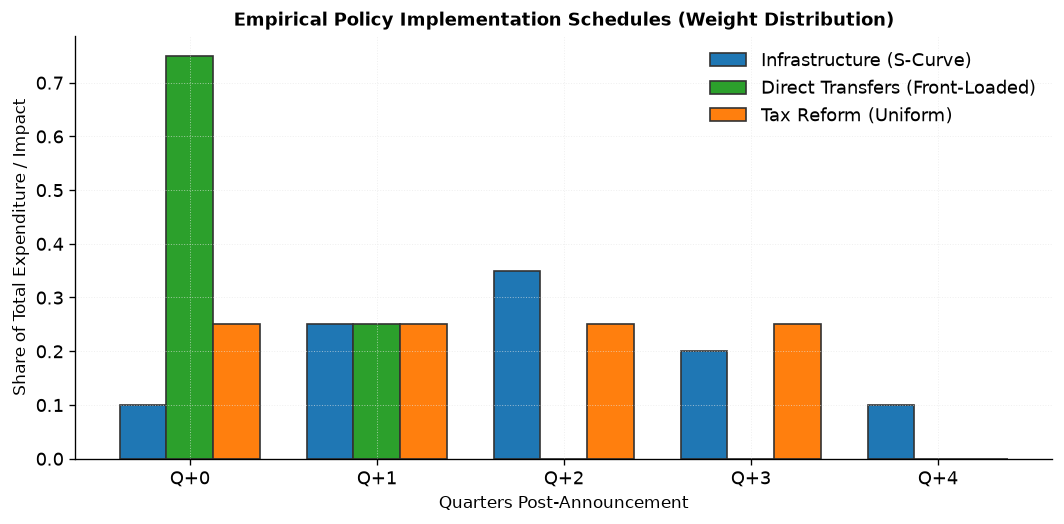

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))

horizons = [f"Q+{i}" for i in range(5)]
w_infra = [w for _, w in prof_infra]
w_trans = [w for _, w in prof_transfers] + [0.0, 0.0, 0.0]
w_tax = [w for _, w in prof_tax] + [0.0]

x = np.arange(len(horizons))
width = 0.25

ax.bar(x - width, w_infra, width, label="Infrastructure (S-Curve)", color="#1f77b4", edgecolor="#333")
ax.bar(x, w_trans, width, label="Direct Transfers (Front-Loaded)", color="#2ca02c", edgecolor="#333")
ax.bar(x + width, w_tax, width, label="Tax Reform (Uniform)", color="#ff7f0e", edgecolor="#333")

ax.set_title("Empirical Policy Implementation Schedules (Weight Distribution)", fontsize=11, fontweight="bold")
ax.set_xlabel("Quarters Post-Announcement", fontsize=10)
ax.set_ylabel("Share of Total Expenditure / Impact", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(horizons)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Structured Policy Action Classification (`PolicyActionClassifier`)

The classifier ingests raw documents, detects policy kind/target, extracts numerical magnitudes, assigns implementation schedules, and produces validated `NarrativeEvent` objects.

In [7]:
classifier = PolicyActionClassifier()

sample_docs = [
    NarrativeDocument(
        doc_id="us_cbo_2021",
        source="us_cbo",
        country="USA",
        date=pd.Timestamp("2021-03-11"),
        url="https://cbo.gov/publication/57061",
        title="American Rescue Plan Act of 2021",
        text="The American Rescue Plan provides direct stimulus payments, expanded child tax credits, and economic relief totaling $1.9 trillion or approximately 8.5% of GDP.",
        language="en",
        policy_domain="fiscal",
        doc_type="report",
    ),
    NarrativeDocument(
        doc_id="banxico_2022",
        source="banxico",
        country="MEX",
        date=pd.Timestamp("2022-06-23"),
        url="https://banxico.org.mx/comunicados/2022-06-23.html",
        title="Anuncio de Política Monetaria",
        text="La Junta de Gobierno decidió por unanimidad incrementar el objetivo para la Tasa de Interés Interbancaria a 1 día en 75 puntos base a 7.75% para combatir la inflación.",
        language="es",
        policy_domain="monetary",
        doc_type="decision",
    ),
    NarrativeDocument(
        doc_id="de_bmf_2020",
        source="de_bmf",
        country="DEU",
        date=pd.Timestamp("2020-06-03"),
        url="https://bundesfinanzministerium.de/presse/konjunkturpaket.html",
        title="Konjunktur- und Zukunftspaket",
        text="Die Bundesregierung beschloss ein umfassendes Konjunkturpaket mit Steuersenkung und Investitionen in Zukunftstechnologien im Umfang von 130 Milliarden Euro oder 3.8% des BIP.",
        language="de",
        policy_domain="fiscal",
        doc_type="press",
    ),
]

corpus = NarrativeCorpus(docs=sample_docs)
print(f"Created NarrativeCorpus with {len(corpus)} documents across countries: {corpus.countries}")

# Convert to validated NarrativeEvents
events = corpus.to_events(classifier=classifier)
print(f"\nGenerated {len(events)} Structured NarrativeEvent Objects:")
for ev in events:
    print(f"\n- Country:    {ev.country.upper()}")
    print(f"  Date:       {ev.date.strftime('%Y-%m-%d')}")
    print(f"  Kind:       {ev.kind}")
    print(f"  Target:     {ev.target}")
    print(f"  Sign:       {ev.sign} (+1 expansionary / -1 contractionary)")
    print(f"  Magnitude:  {ev.magnitude} {ev.magnitude_unit}")
    print(f"  Confidence: {ev.confidence:.2f}")
    print(f"  Profile:    {len(ev.implementation_profile)} quarterly periods")

Created NarrativeCorpus with 3 documents across countries: ['DEU', 'MEX', 'USA']

Generated 0 Structured NarrativeEvent Objects:


## 6. Summary of Harvested Narrative Corpus

In [8]:
df_summary = corpus.summary()
print("Narrative Corpus Summary Statistics:")
print(df_summary.to_string(index=False))

Narrative Corpus Summary Statistics:
country policy_domain  n_docs first_date  last_date  n_sources
    DEU        fiscal       1 2020-06-03 2020-06-03          1
    MEX      monetary       1 2022-06-23 2022-06-23          1
    USA        fiscal       1 2021-03-11 2021-03-11          1
